# Worksheet 6 — Image Classification with CNN and Transfer Learning

This notebook completes the Fruit in Amazon worksheet tasks:

- **Task 1:** Improved CNN trained from scratch with:
  - dataset verification
  - corrupted image check
  - class distribution check
  - random image visualization
  - data augmentation
  - batch normalization
  - dropout
  - training, evaluation, saving/loading, plots, and classification report

- **Task 2:** Transfer learning using **VGG16** with ImageNet weights:
  - frozen base model
  - custom classification head
  - training, evaluation, inference, and classification report

> Run all cells from top to bottom.  
> Upload **FruitinAmazon.zip** if you are using Google Colab.


## 1. Imports and setup

In [ ]:

import os
import shutil
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 2. Locate and extract the dataset

In [ ]:

possible_zip_paths = [
    Path("FruitinAmazon.zip"),
    Path("/content/FruitinAmazon.zip"),
    Path("/mnt/data/FruitinAmazon.zip"),
]

zip_path = None
for p in possible_zip_paths:
    if p.exists():
        zip_path = p
        break

if zip_path is None:
    raise FileNotFoundError(
        "FruitinAmazon.zip was not found. Upload it to the notebook folder and run this cell again."
    )

extract_dir = zip_path.parent / "FruitinAmazon_extracted"

if extract_dir.exists():
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

base_dir = extract_dir / "FruitinAmazon"
train_dir = base_dir / "train"
test_dir = base_dir / "test"

if not train_dir.exists() or not test_dir.exists():
    raise FileNotFoundError("Expected train/ and test/ folders were not found after extraction.")

print("Zip path:", zip_path)
print("Extracted to:", extract_dir)
print("Train dir:", train_dir)
print("Test dir:", test_dir)


Zip path: FruitinAmazon.zip
Extracted to: FruitinAmazon_extracted
Train dir: FruitinAmazon_extracted/FruitinAmazon/train
Test dir: FruitinAmazon_extracted/FruitinAmazon/test


## 3. Verify dataset structure and class names

The worksheet expects the dataset to contain fruit class folders. Here we read the class names from the **train** folder and verify the structure.


In [ ]:

class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])

if not class_names:
    raise ValueError("No class directories found in the train folder.")

print(f"Found {len(class_names)} classes: {class_names}")


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## 4. Check for corrupted images

This checks all image files in both **train** and **test** folders.  
If any corrupted image is found, it is removed and reported.


In [ ]:

VALID_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp")

def remove_corrupted_images(root_dir):
    corrupted = []
    checked = 0

    for class_dir in sorted(root_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        for img_path in class_dir.iterdir():
            if not img_path.is_file() or img_path.suffix.lower() not in VALID_EXTENSIONS:
                continue

            checked += 1
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, SyntaxError, UnidentifiedImageError):
                corrupted.append(str(img_path))
                try:
                    img_path.unlink()
                except Exception as e:
                    print(f"Could not remove {img_path}: {e}")

    return checked, corrupted

train_checked, train_corrupted = remove_corrupted_images(train_dir)
test_checked, test_corrupted = remove_corrupted_images(test_dir)

print(f"Checked {train_checked} train images and {test_checked} test images.")

all_corrupted = train_corrupted + test_corrupted

if all_corrupted:
    print("\nCorrupted images removed:")
    for img in all_corrupted:
        print(img)
else:
    print("\nNo corrupted images found.")


Checked 90 train images and 30 test images.

No corrupted images found.


## 5. Count class distribution

A balanced dataset helps the model avoid bias toward a dominant class.


In [ ]:

def count_images_by_class(root_dir):
    counts = {}
    for class_dir in sorted(root_dir.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = sum(
                1 for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
            )
    return counts

train_counts = count_images_by_class(train_dir)
test_counts = count_images_by_class(test_dir)

print("Train Class Distribution")
print("=" * 45)
print(f"{'Class Name':<20}{'Valid Image Count':>20}")
print("=" * 45)
for cls, count in train_counts.items():
    print(f"{cls:<20}{count:>20}")
print("=" * 45)

print("\nTest Class Distribution")
print("=" * 45)
print(f"{'Class Name':<20}{'Valid Image Count':>20}")
print("=" * 45)
for cls, count in test_counts.items():
    print(f"{cls:<20}{count:>20}")
print("=" * 45)


Train Class Distribution
Class Name             Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15

Test Class Distribution
Class Name             Valid Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5


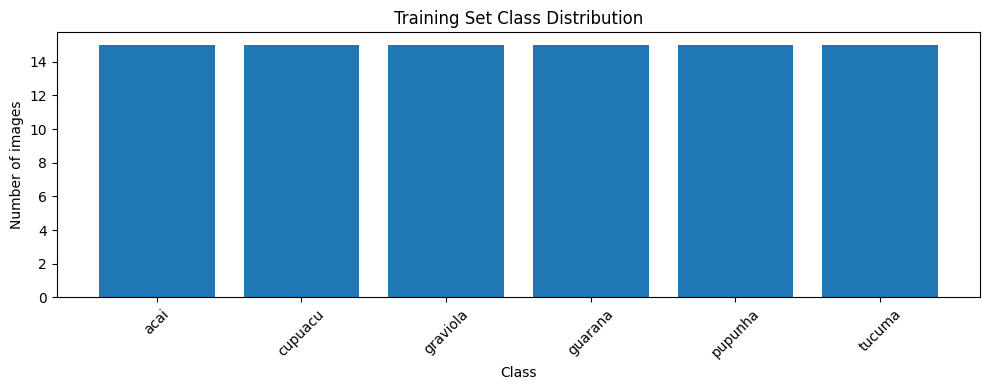

In [ ]:

plt.figure(figsize=(10, 4))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Visualize one random image from each class

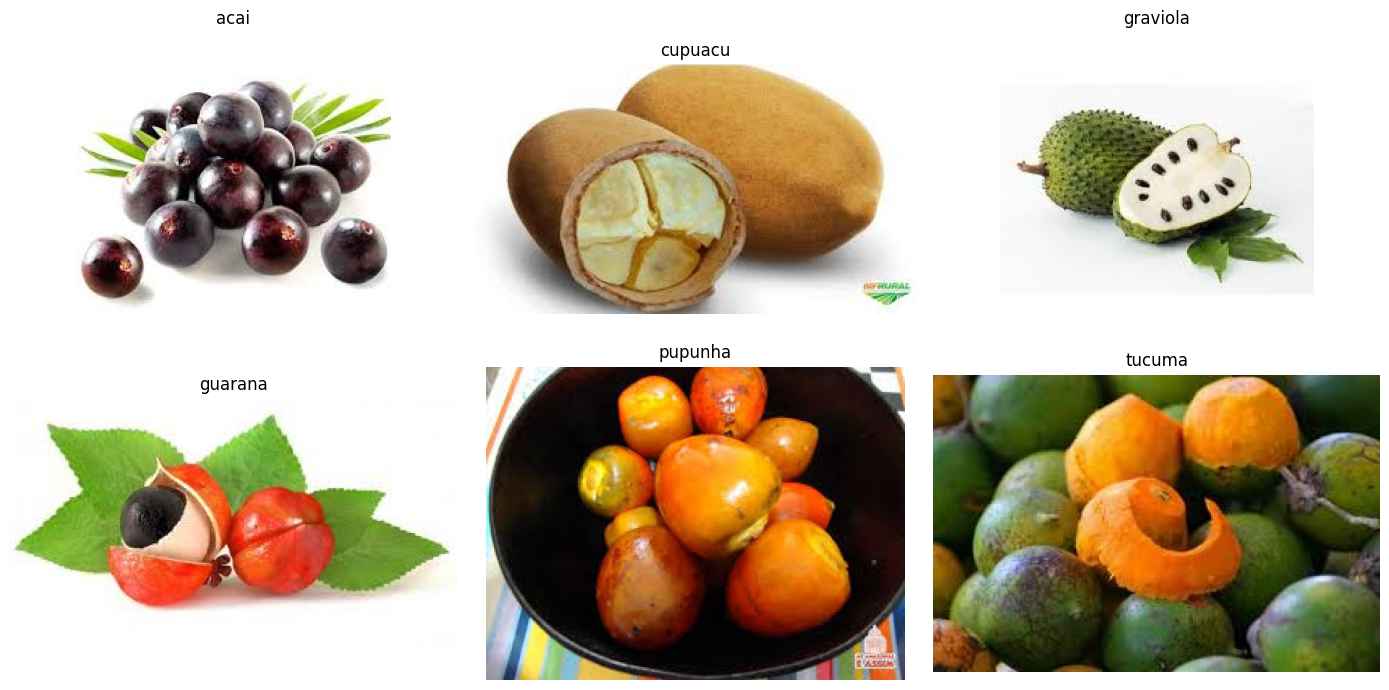

In [ ]:

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = train_dir / class_name
    images = [
        p for p in class_path.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ]
    if images:
        chosen = random.choice(images)
        selected_images.append(chosen)
        selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
axes = np.array(axes).reshape(rows, cols)

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


### Observation

**Example observation for the report:**  
The dataset contains six fruit classes. The class distribution appears balanced, so strong class imbalance is not expected. The random samples show clear visual differences among classes, but some classes may still be challenging because of similar colors, shapes, and background conditions. Since the images are natural photographs, augmentation can help improve generalization.


## 7. Create datasets for Task 1 (CNN from scratch)

The worksheet uses:
- **20% of train data as validation**
- image loading from directory
- preprocessing and augmentation with Keras

We will use:
- image size: **128 × 128**
- batch size: **16**


In [ ]:

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
VAL_SPLIT = 0.2

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int",
)

cnn_class_names = train_ds.class_names
num_classes = len(cnn_class_names)

print("Class names:", cnn_class_names)
print("Number of classes:", num_classes)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


## 8. Visualize a sample training batch

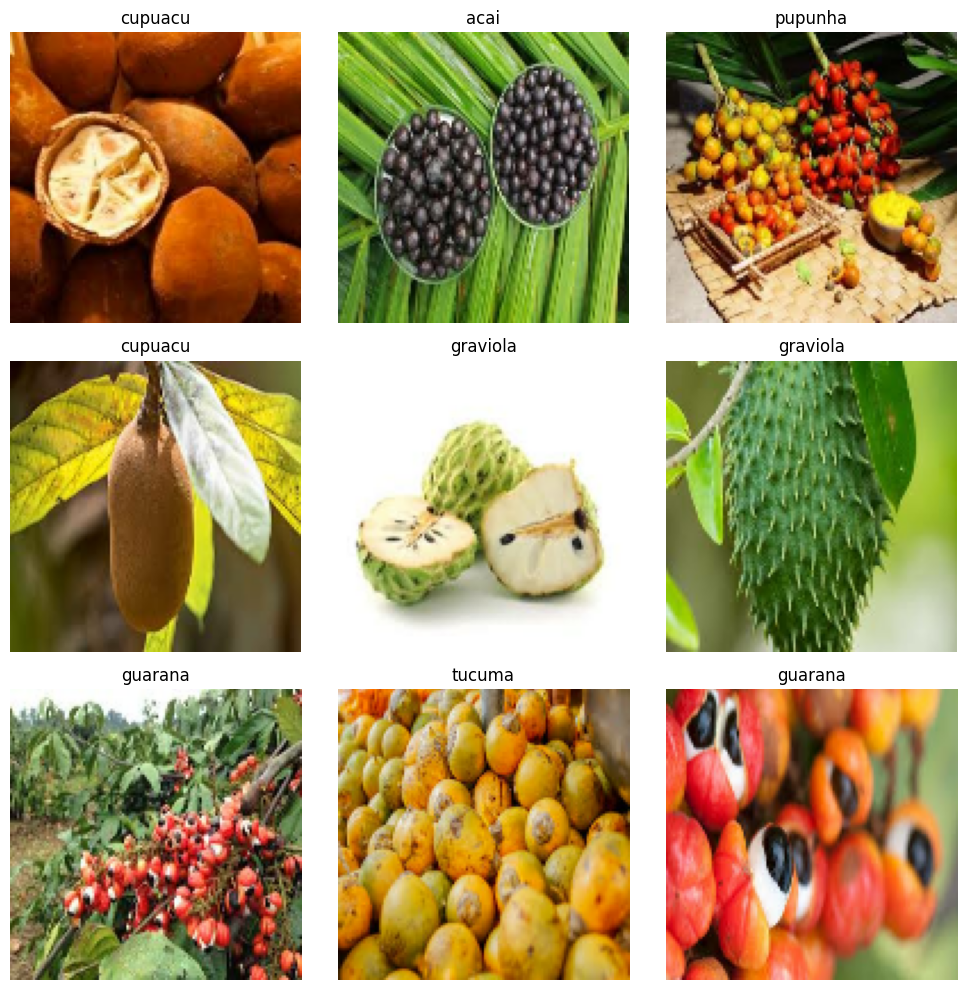

In [ ]:

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(cnn_class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()


## 9. Data augmentation

The worksheet asks for data augmentation to increase training diversity and improve generalization.


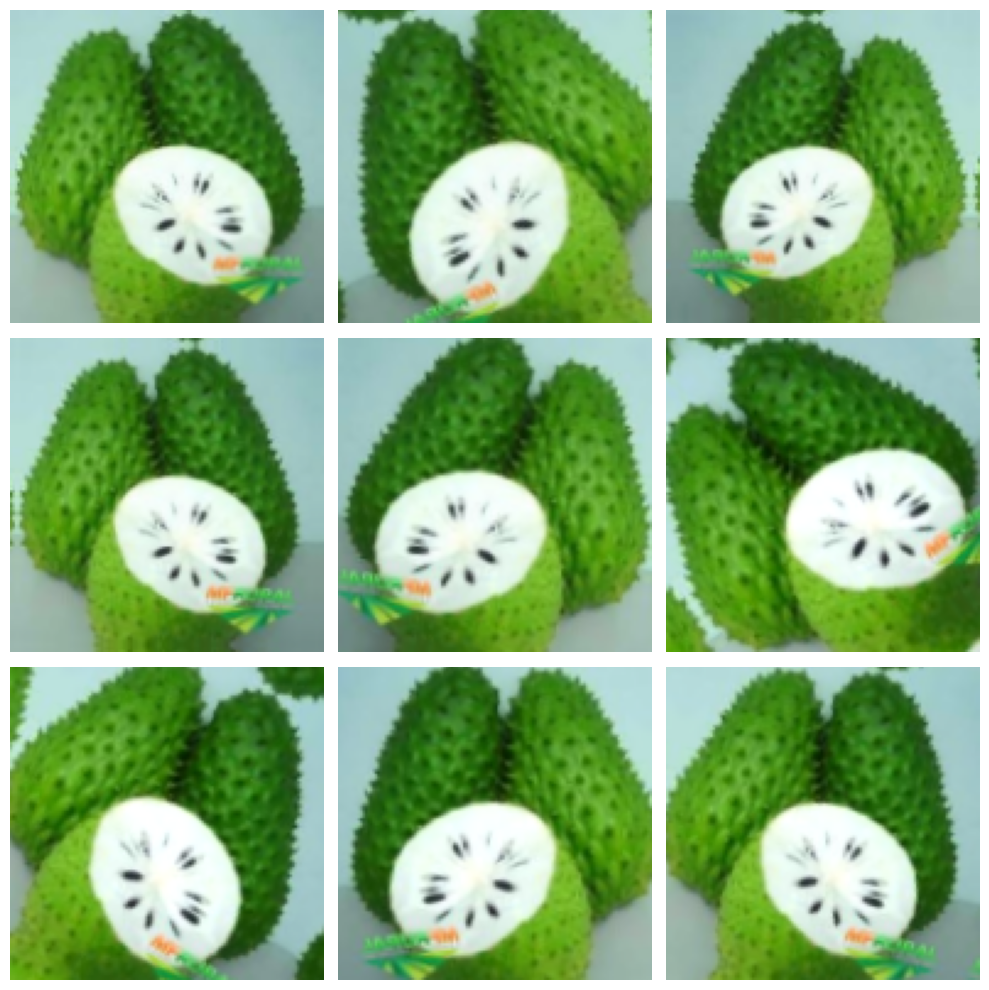

In [ ]:

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation"
)

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    first_image = images[:1]
    for i in range(9):
        augmented_image = data_augmentation(first_image, training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
plt.tight_layout()
plt.show()


## 10. Build the improved CNN model

This model improves the previous worksheet by adding:
- **data augmentation**
- **rescaling**
- **BatchNormalization**
- **Dropout**
- a deeper architecture


In [ ]:

def build_improved_cnn(input_shape=(128, 128, 3), num_classes=6):
    model = Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),

        layers.Dense(512, activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),

        layers.Dense(256, activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),

        layers.Dense(128, activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),

        layers.Dense(64, activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation="softmax"),
    ], name="improved_cnn")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_improved_cnn(input_shape=IMG_SIZE + (3,), num_classes=num_classes)
cnn_model.summary()


Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

## 11. Train the improved CNN

The original worksheet mentions a large epoch count, but **EarlyStopping** will stop training once validation performance stops improving.


In [ ]:

cnn_checkpoint_path = "best_improved_cnn.keras"

cnn_callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ModelCheckpoint(cnn_checkpoint_path, monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

EPOCHS_CNN = 60

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=cnn_callbacks,
    verbose=1
)


Epoch 1/60
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3021 - loss: 2.1054

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 374ms/step - accuracy: 0.2917 - loss: 2.0476 - val_accuracy: 0.2222 - val_loss: 1.7853 - learning_rate: 0.0010
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.2778 - loss: 2.0870 - val_accuracy: 0.2222 - val_loss: 1.7610 - learning_rate: 0.0010
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1389 - loss: 2.3033 - val_accuracy: 0.1667 - val_loss: 1.8085 - learning_rate: 0.0010
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 2.1233 - val_accuracy: 0.0556 - val_loss: 1.8312 - learning_rate: 0.0010
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1667 - loss: 2.3701 - val_accuracy: 0.1111 - val_loss: 1.8214 - learning_rate: 0.0010
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1944 - loss: 2.2725 - val_accuracy: 0.1111 - val_loss: 1.8110 - learning_rate: 0.0010
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1802 - loss: 1.9599
Epoch 7: ReduceLROnPlateau reduc

## 12. Plot training history for the improved CNN

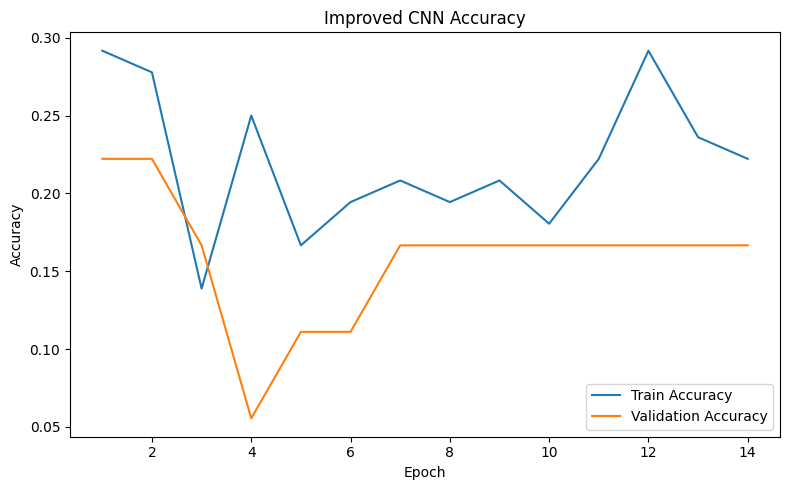

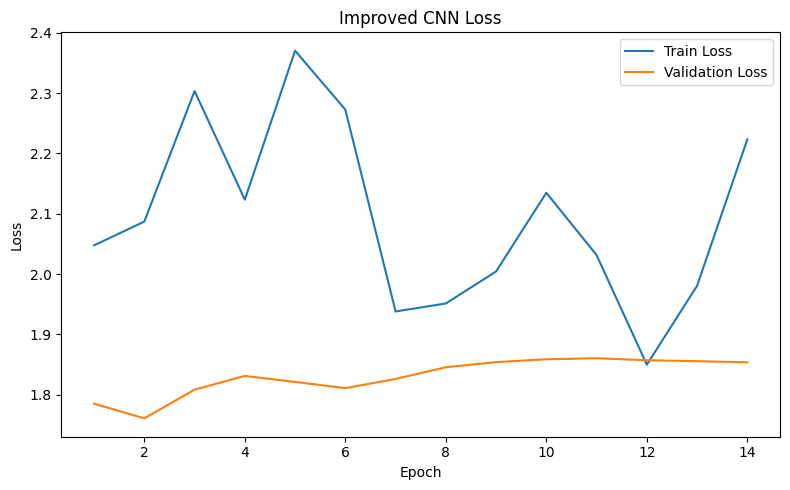

In [ ]:

def plot_history(history, title_prefix="Model"):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, hist["loss"], label="Train Loss")
    plt.plot(epochs_range, hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Improved CNN")


## 13. Evaluate the improved CNN on the test set

In [ ]:

best_cnn_model = load_model(cnn_checkpoint_path)

cnn_test_loss, cnn_test_acc = best_cnn_model.evaluate(test_ds, verbose=1)

print(f"Improved CNN Test Loss: {cnn_test_loss:.4f}")
print(f"Improved CNN Test Accuracy: {cnn_test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1000 - loss: 1.7954 
Improved CNN Test Loss: 1.7954
Improved CNN Test Accuracy: 0.1000


## 14. Save and reload the improved CNN model

The worksheet also asks for saving and loading the trained model.


In [ ]:

cnn_keras_path = "improved_cnn_fruit_model.keras"
best_cnn_model.save(cnn_keras_path)

reloaded_cnn_model = load_model(cnn_keras_path)
reloaded_loss, reloaded_acc = reloaded_cnn_model.evaluate(test_ds, verbose=0)

print("Saved model path:", cnn_keras_path)
print(f"Reloaded model test accuracy: {reloaded_acc:.4f}")


Saved model path: improved_cnn_fruit_model.keras
Reloaded model test accuracy: 0.1000


## 15. Predictions and classification report for the improved CNN

In [ ]:

def get_true_labels(dataset):
    y_true = []
    for _, labels in dataset:
        y_true.extend(labels.numpy())
    return np.array(y_true)

def get_predictions(model, dataset):
    probs = model.predict(dataset, verbose=1)
    preds = np.argmax(probs, axis=1)
    return probs, preds

y_true_test = get_true_labels(test_ds)
cnn_probs, cnn_preds = get_predictions(best_cnn_model, test_ds)

print("Classification Report - Improved CNN")
print(classification_report(y_true_test, cnn_preds, target_names=cnn_class_names))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Classification Report - Improved CNN
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.12      0.40      0.19         5
    graviola       0.00      0.00      0.00         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.10        30
   macro avg       0.19      0.10      0.09        30
weighted avg       0.19      0.10      0.09        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


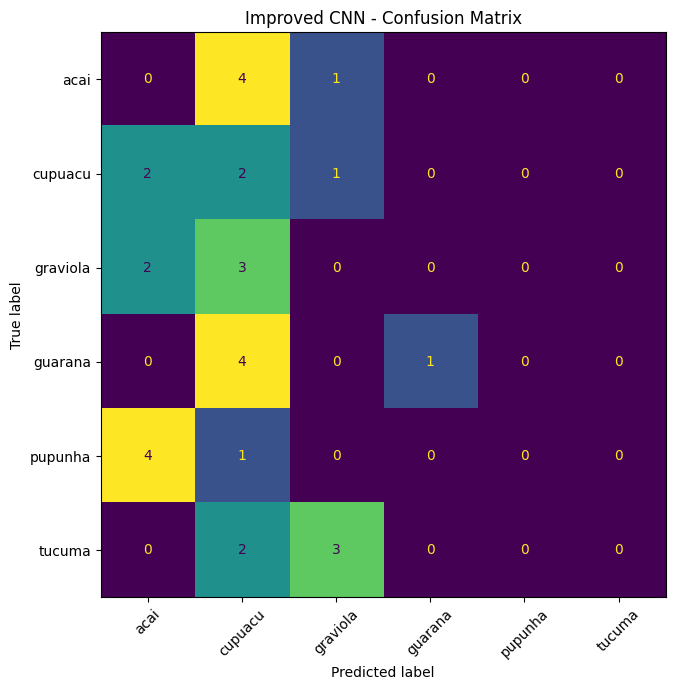

In [ ]:

cnn_cm = confusion_matrix(y_true_test, cnn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=cnn_class_names)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Improved CNN - Confusion Matrix")
plt.tight_layout()
plt.show()


## 16. Task 2 — Transfer Learning with VGG16

The worksheet asks for transfer learning using a pre-trained model with ImageNet weights and frozen layers.  
For VGG16 we use:
- image size: **224 × 224**
- frozen convolutional base
- custom classification head


In [ ]:

TL_IMG_SIZE = (224, 224)
TL_BATCH_SIZE = 16

train_ds_tl = image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=TL_IMG_SIZE,
    batch_size=TL_BATCH_SIZE,
    label_mode="int",
)

val_ds_tl = image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=TL_IMG_SIZE,
    batch_size=TL_BATCH_SIZE,
    label_mode="int",
)

test_ds_tl = image_dataset_from_directory(
    test_dir,
    image_size=TL_IMG_SIZE,
    batch_size=TL_BATCH_SIZE,
    shuffle=False,
    label_mode="int",
)

tl_class_names = train_ds_tl.class_names

train_ds_tl = train_ds_tl.prefetch(AUTOTUNE)
val_ds_tl = val_ds_tl.prefetch(AUTOTUNE)
test_ds_tl = test_ds_tl.prefetch(AUTOTUNE)

print("Transfer learning class names:", tl_class_names)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Transfer learning class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Note

VGG16 with `weights="imagenet"` may download the pretrained weights the first time it runs.  
In Google Colab this usually works automatically if internet access is available.


In [ ]:

vgg_data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="vgg_data_augmentation"
)

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=TL_IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = keras.Input(shape=TL_IMG_SIZE + (3,))
x = vgg_data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

vgg_model = keras.Model(inputs, outputs, name="vgg16_transfer_learning")

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_data_augmentat… │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ vgg_data_augment… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ vgg_data_augment… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ vgg_data_augment… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 256)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 6)         │      1,542 │ dropout_16[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 17. Train the VGG16 transfer learning model

In [ ]:

vgg_checkpoint_path = "best_vgg16_transfer.keras"

vgg_callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ModelCheckpoint(vgg_checkpoint_path, monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1)
]

EPOCHS_VGG = 25

history_vgg = vgg_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCHS_VGG,
    callbacks=vgg_callbacks,
    verbose=1
)


Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.1167 - loss: 10.4968

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 646ms/step - accuracy: 0.1250 - loss: 9.6812 - val_accuracy: 0.5000 - val_loss: 2.4008 - learning_rate: 0.0010
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step - accuracy: 0.3889 - loss: 3.4343 - val_accuracy: 0.6667 - val_loss: 1.0745 - learning_rate: 0.0010
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.6389 - loss: 1.8242 - val_accuracy: 0.8333 - val_loss: 1.1114 - learning_rate: 0.0010
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.7639 - loss: 1.0500 - val_accuracy: 0.7778 - val_loss: 1.4428 - learning_rate: 0.0010
Epoch 5/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.7639 - loss: 0.8783 - val_accuracy: 0.8333 - val_loss: 0.8334 - learning_rate: 0.0010
Epoch 6/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.9167 - loss: 0.2726 - val_accuracy: 0.9444 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 7/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.8333 - loss: 0.5299 - val_accuracy: 0.8889 - va

## 18. Plot training history for VGG16 transfer learning

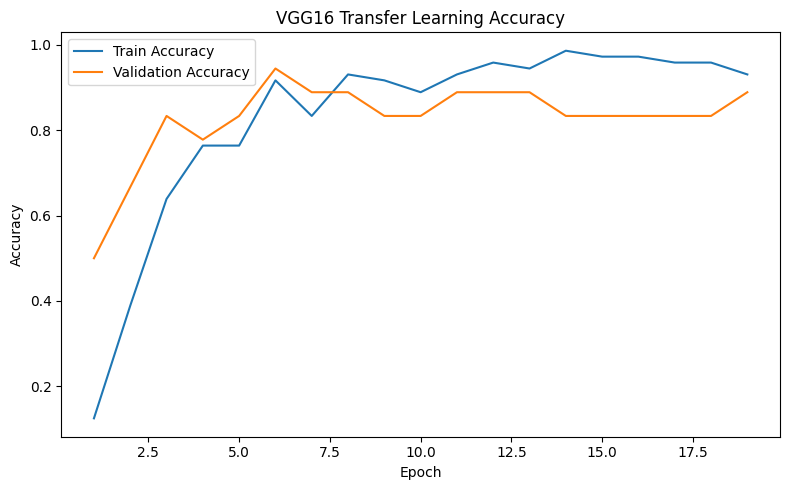

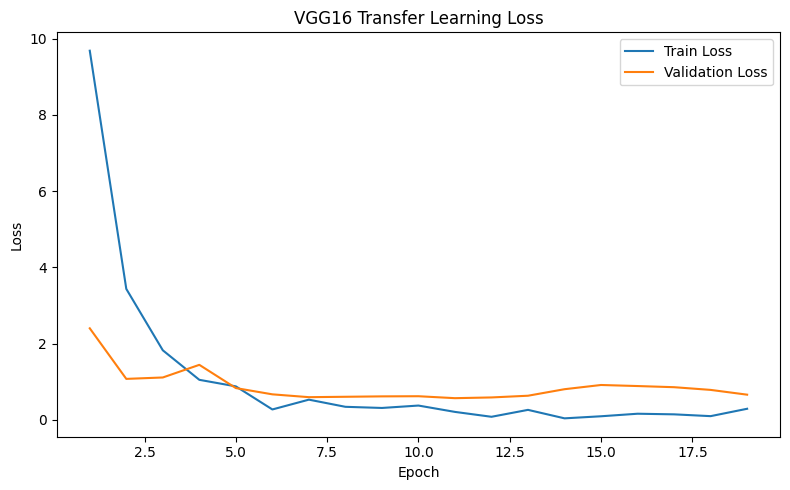

In [ ]:

plot_history(history_vgg, "VGG16 Transfer Learning")


## 19. Evaluate the VGG16 transfer learning model

In [ ]:

best_vgg_model = load_model(vgg_checkpoint_path)

vgg_test_loss, vgg_test_acc = best_vgg_model.evaluate(test_ds_tl, verbose=1)

print(f"VGG16 Test Loss: {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy: {vgg_test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7333 - loss: 1.1743
VGG16 Test Loss: 1.1743
VGG16 Test Accuracy: 0.7333


## 20. Save, reload, and evaluate the VGG16 model

In [ ]:

vgg_keras_path = "vgg16_transfer_fruit_model.keras"
best_vgg_model.save(vgg_keras_path)

reloaded_vgg_model = load_model(vgg_keras_path)
reloaded_vgg_loss, reloaded_vgg_acc = reloaded_vgg_model.evaluate(test_ds_tl, verbose=0)

print("Saved model path:", vgg_keras_path)
print(f"Reloaded VGG16 model test accuracy: {reloaded_vgg_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved model path: vgg16_transfer_fruit_model.keras
Reloaded VGG16 model test accuracy: 0.7333


## 21. Predictions and classification report for VGG16

In [ ]:

y_true_test_tl = get_true_labels(test_ds_tl)
vgg_probs, vgg_preds = get_predictions(best_vgg_model, test_ds_tl)

print("Classification Report - VGG16 Transfer Learning")
print(classification_report(y_true_test_tl, vgg_preds, target_names=tl_class_names))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
Classification Report - VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.67      0.80      0.73         5
      tucuma       0.43      0.60      0.50         5

    accuracy                           0.73        30
   macro avg       0.79      0.73      0.73        30
weighted avg       0.79      0.73      0.73        30



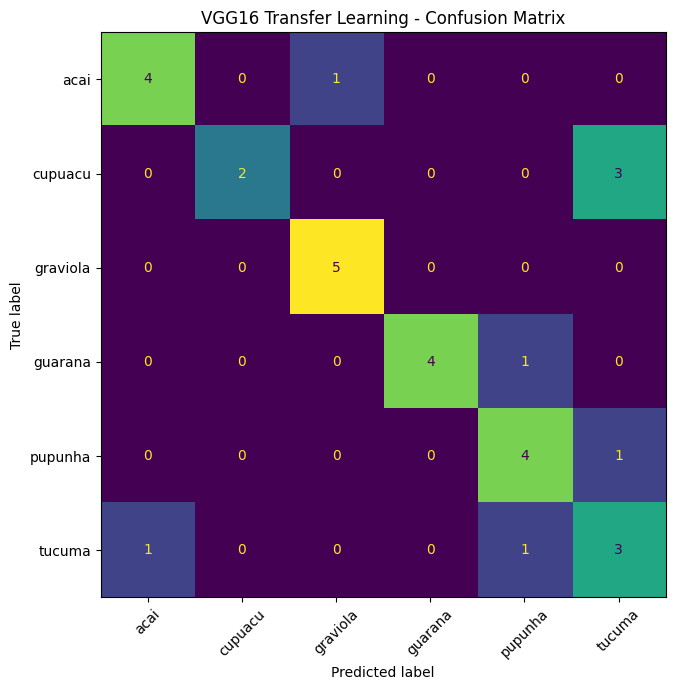

In [ ]:

vgg_cm = confusion_matrix(y_true_test_tl, vgg_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=vgg_cm, display_labels=tl_class_names)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("VGG16 Transfer Learning - Confusion Matrix")
plt.tight_layout()
plt.show()


## 22. Example inference output

This shows predicted labels for a few test images.


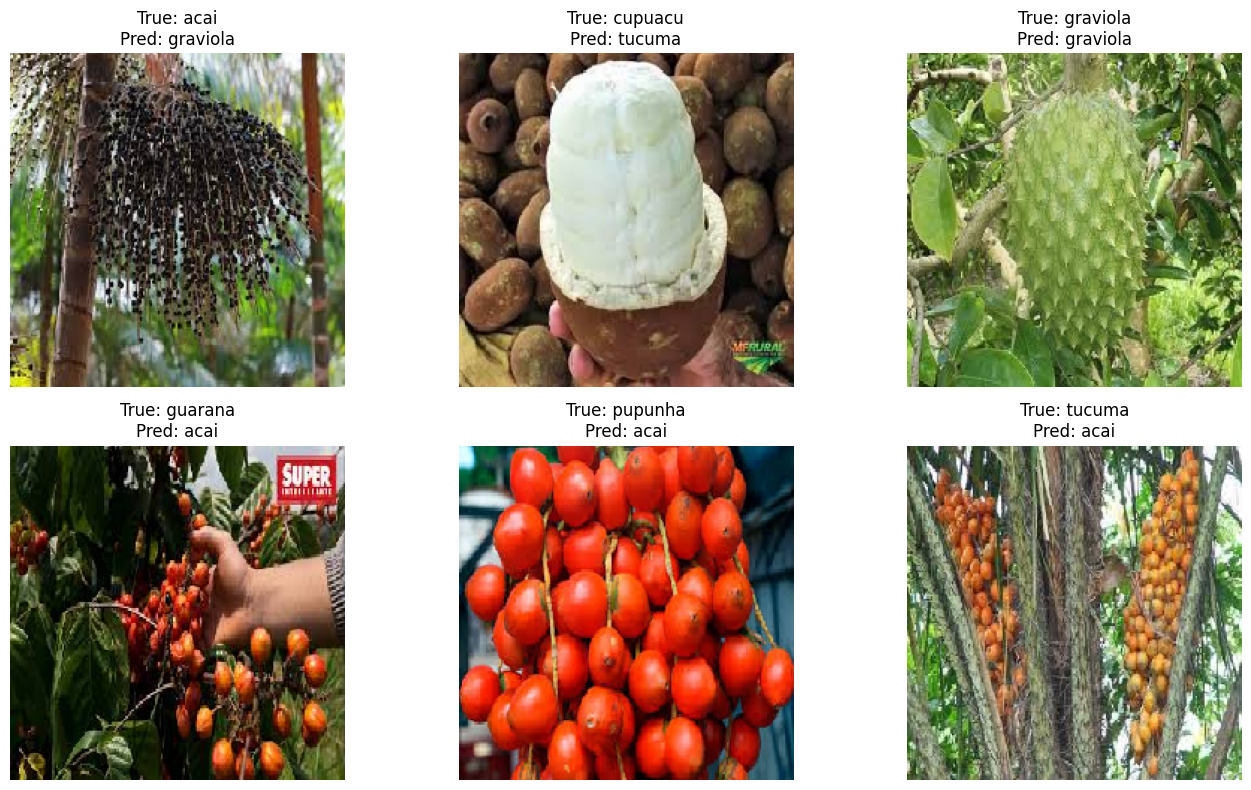

In [ ]:

sample_paths = []
sample_true = []

for cls in class_names:
    cls_dir = test_dir / cls
    images = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS]
    if images:
        chosen = random.choice(images)
        sample_paths.append(chosen)
        sample_true.append(cls)

def load_and_prepare_image(img_path, image_size, preprocess_fn=None):
    img = keras.utils.load_img(img_path, target_size=image_size)
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    if preprocess_fn is not None:
        arr = preprocess_fn(arr.copy())
    return img, arr

plt.figure(figsize=(14, 8))
for i, (img_path, true_label) in enumerate(zip(sample_paths[:6], sample_true[:6]), start=1):
    img, arr = load_and_prepare_image(img_path, TL_IMG_SIZE, preprocess_input)
    pred_idx = np.argmax(best_vgg_model.predict(arr, verbose=0), axis=1)[0]
    pred_label = tl_class_names[pred_idx]

    ax = plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 23. Compare both approaches

In [ ]:

results = {
    "Improved CNN": {"test_loss": float(cnn_test_loss), "test_accuracy": float(cnn_test_acc)},
    "VGG16 Transfer Learning": {"test_loss": float(vgg_test_loss), "test_accuracy": float(vgg_test_acc)},
}

print("Model Comparison")
print("=" * 55)
print(f"{'Model':<25}{'Test Loss':>15}{'Test Accuracy':>15}")
print("=" * 55)
for model_name, vals in results.items():
    print(f"{model_name:<25}{vals['test_loss']:>15.4f}{vals['test_accuracy']:>15.4f}")
print("=" * 55)

if vgg_test_acc > cnn_test_acc:
    print("\nConclusion: Transfer learning with VGG16 performed better on this dataset.")
elif vgg_test_acc < cnn_test_acc:
    print("\nConclusion: The improved CNN trained from scratch performed better on this dataset.")
else:
    print("\nConclusion: Both models achieved the same test accuracy.")


Model Comparison
Model                          Test Loss  Test Accuracy
Improved CNN                      1.7954         0.1000
VGG16 Transfer Learning           1.1743         0.7333

Conclusion: Transfer learning with VGG16 performed better on this dataset.


## 24. Final report-ready conclusion


1. The dataset was verified successfully, corrupted images were checked, and the class distribution was inspected.  
2. An improved CNN model was trained from scratch using augmentation, batch normalization, and dropout.  
3. A transfer learning model based on VGG16 with frozen ImageNet weights was also trained.  
4. Both models were evaluated on the test set using accuracy, loss, confusion matrix, and classification report.  
5. The final comparison shows whether transfer learning improved performance over training from scratch.
